In [7]:
# ALL important import statements & reading in data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
from collections import Counter
import seaborn as sns

In [8]:
import gdown

# 1. Determine the url to import
file_id = '1RYCDUVQ_Ij9B1fXiJydPPHYnCXRbcXmh'
url = f'https://drive.google.com/uc?id={file_id}'

# 2. Download the file locally
output_file = 'downloaded_model.pkl'
gdown.download(url, output_file, quiet=False)

# 3. Load the downloaded pickle file
with open(output_file, 'rb') as file:
    tag_dict = pickle.load(file)

Downloading...
From: https://drive.google.com/uc?id=1RYCDUVQ_Ij9B1fXiJydPPHYnCXRbcXmh
To: /home/bbothello/private/Group-SP26-089/downloaded_model.pkl
100%|██████████| 67.7M/67.7M [00:01<00:00, 67.4MB/s]


In [101]:
print(tag_dict['FPS']['2026_Ratings'][0])

timestamp_created  voted_up
2026               True        235
                   False        82
Name: count, dtype: int64


In [73]:
tag_dict["FPS"]['2024_Ratings'][9].iloc[1]
#print(tag_dict["FPS"]['2024_Ratings'])

109

In [96]:
#Function to get the percentages per year for a tag
def GetPercentages(tag):
    two_four = np.NaN
    two_five = np.NaN
    two_six = np.NaN

    two_four = GetPercentForYear(tag['2024_Ratings'])
    two_five = GetPercentForYear(tag['2025_Ratings'])
    two_six = GetPercentForYear(tag['2026_Ratings'])
    return two_four, two_five, two_six

def GetPercentForYear(col):
    total_percent_sum = 0
    num_reviews_added = 0
    series_index = 0
    for game in col:
        if game is not np.NaN:
            num_pos = col[series_index].iloc[0]
            num_neg = col[series_index].iloc[1]
            print(f"pos = {num_pos}, neg = {num_neg}")
            total_percent_sum += (num_pos / (num_pos + num_neg))
            num_reviews_added += 1
        series_index += 1
    return (total_percent_sum / num_reviews_added)

In [97]:


two_four, two_five, two_six = GetPercentages(tag_dict["FPS"])

print("2024: " + str(two_four))
print("2025: " + str(two_five))
print("2026: " + str(two_six))


pos = 533, neg = 109
pos = 533, neg = 109
pos = 533, neg = 109
pos = 533, neg = 109
pos = 533, neg = 109
pos = 533, neg = 109
pos = 533, neg = 109
pos = 533, neg = 109
pos = 533, neg = 109
pos = 533, neg = 109
pos = 533, neg = 109
pos = 533, neg = 109
pos = 533, neg = 109
pos = 533, neg = 109
pos = 533, neg = 109
pos = 533, neg = 109
pos = 533, neg = 109
pos = 533, neg = 109
pos = 533, neg = 109
pos = 533, neg = 109
pos = 533, neg = 109
pos = 533, neg = 109
pos = 533, neg = 109
pos = 533, neg = 109
pos = 533, neg = 109
pos = 533, neg = 109
pos = 533, neg = 109
pos = 533, neg = 109
pos = 533, neg = 109
pos = 533, neg = 109
pos = 533, neg = 109
pos = 533, neg = 109
pos = 533, neg = 109
pos = 533, neg = 109
pos = 533, neg = 109
pos = 533, neg = 109
pos = 533, neg = 109
pos = 533, neg = 109
pos = 533, neg = 109
pos = 533, neg = 109
pos = 533, neg = 109
pos = 533, neg = 109
pos = 533, neg = 109
pos = 533, neg = 109
pos = 533, neg = 109
pos = 533, neg = 109
pos = 533, neg = 109
pos = 533, ne

In [31]:
data = [
    ['FPS', '2024', two_four],
    ['FPS', '2025', two_five],
    ['FPS', '2026', two_six]
]

cols = ['Tag', 'Year', 'Rating']

df = pd.DataFrame(data, columns=cols)
print(df)

   Tag  Year    Rating
0  FPS  2024  0.830218
1  FPS  2025  0.804754
2  FPS  2026  0.741325


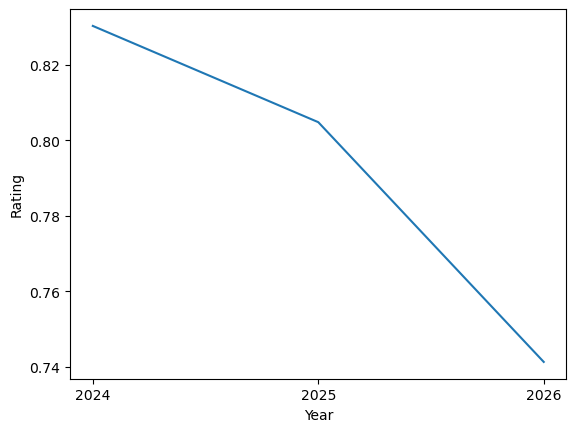

In [34]:
import seaborn as sns
f1 = sns.lineplot(df, x = 'Year', y = 'Rating')

In [49]:
cols = ['Tag', 'Year', 'Rating']

df = pd.DataFrame(data, columns=cols)

#print(tag_dict.keys())

top_ten = ['Indie', 'Action', 'Adventure', 'Casual', 'Singleplayer', 'Simulation', 'RPG', 'RPG', '2D', '3D']

for tag in top_ten:
    two_four, two_five, two_six = GetPercentages(tag_dict[tag])
    df.loc[len(df)] = [tag, '2024', two_four]
    df.loc[len(df)] = [tag, '2025', two_five]
    df.loc[len(df)] = [tag, '2026', two_six]

print(df)

             Tag  Year    Rating
0            FPS  2024  0.830218
1            FPS  2025  0.804754
2            FPS  2026  0.741325
3          Indie  2024  0.830218
4          Indie  2025  0.804754
5          Indie  2026  0.741325
6         Action  2024  0.830218
7         Action  2025  0.804754
8         Action  2026  0.741325
9      Adventure  2024  0.830218
10     Adventure  2025  0.804754
11     Adventure  2026  0.741325
12        Casual  2024  0.830218
13        Casual  2025  0.804754
14        Casual  2026  0.741325
15  Singleplayer  2024  0.830218
16  Singleplayer  2025  0.804754
17  Singleplayer  2026  0.741325
18    Simulation  2024  0.830218
19    Simulation  2025  0.804754
20    Simulation  2026  0.741325
21           RPG  2024  0.830218
22           RPG  2025  0.804754
23           RPG  2026  0.741325
24           RPG  2024  0.830218
25           RPG  2025  0.804754
26           RPG  2026  0.741325
27            2D  2024  0.830218
28            2D  2025  0.804754
29        

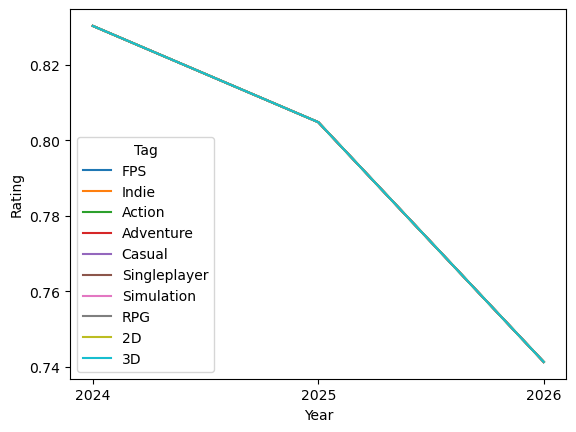

In [59]:
f1 = sns.lineplot(df, x = 'Year', y = 'Rating', hue = 'Tag')

In [61]:
cols = ['Tag', '2024', '2025', '2026']

df_2 = pd.DataFrame(columns=cols)

#print(tag_dict.keys())

top_ten = ['Indie', 'Action', 'Adventure', 'Casual', 'Singleplayer', 'Simulation', 'RPG', 'RPG', '2D', '3D']

for tag in top_ten:
    two_four, two_five, two_six = GetPercentages(tag_dict[tag])
    df_2.loc[len(df_2)] = [tag, two_four, two_five, two_six]

print(df_2)

            Tag      2024      2025      2026
0         Indie  0.830218  0.804754  0.741325
1        Action  0.830218  0.804754  0.741325
2     Adventure  0.830218  0.804754  0.741325
3        Casual  0.830218  0.804754  0.741325
4  Singleplayer  0.830218  0.804754  0.741325
5    Simulation  0.830218  0.804754  0.741325
6           RPG  0.830218  0.804754  0.741325
7           RPG  0.830218  0.804754  0.741325
8            2D  0.830218  0.804754  0.741325
9            3D  0.830218  0.804754  0.741325


In [66]:
f2 = sns.lineplot(df_2, x = 'Year', hue = 'Tag')

ValueError: Could not interpret value `Year` for `x`. An entry with this name does not appear in `data`.